<a href="https://colab.research.google.com/github/ashhwiithac22/Adversarial_Patch_Detection_for_Military_Drones/blob/main/AI_Firewall_For_Drones_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Import

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True) #connects google drive to colab

Mounted at /content/drive


In [2]:
import os
if os.path.exists('/content/drive/MyDrive'):
    print(" Drive already mounted")
else:
    from google.colab import drive
    drive.mount('/content/drive')

 Drive already mounted


In [3]:
from google.colab import drive
import time

max_attempts = 3
for attempt in range(max_attempts):
    try:
        drive.mount('/content/drive', force_remount=True)
        print(" Drive mounted successfully")
        break
    except Exception as e:
        print(f"Attempt {attempt + 1} failed: {e}")
        if attempt < max_attempts - 1:
            print("Retrying in 5 seconds...")
            time.sleep(5)
        else:
            print(" All mount attempts failed")
            raise

Mounted at /content/drive
 Drive mounted successfully


In [4]:
import os
!mkdir -p /content/drive/MyDrive/AI_Firewall_For_Drones
%cd /content/drive/MyDrive/AI_Firewall_For_Drones
!pwd

/content/drive/MyDrive/AI_Firewall_For_Drones
/content/drive/MyDrive/AI_Firewall_For_Drones


In [5]:
!pip install torch torchvision torchattacks --quiet
!pip install kaggle pandas numpy scikit-learn tqdm --quiet
!pip install opencv-python pillow imagehash --quiet
!pip install matplotlib seaborn --quiet
import torch
print(f"PyTorch: {torch.__version__}")
print(f" CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
google-genai 1.68.0 requires requests<3.0.0,>=2.28.1, but you have requests 2.25.1 which is incompatible.
tiktoken 0.12.0 requires requests>=2.26.0, but you have requests 2.25.1 which is incompatible.
yfinance 0.2.66 requires requests>=2.31, but you h

In [6]:
import os
os.environ['KAGGLE_USERNAME'] = 'Ashwitha C'
os.environ['KAGGLE_KEY'] = 'KGAT_ba34d38359b59577be4dc6131fefb151'
print(" Kaggle API configured")
!kaggle --version

 Kaggle API configured
Kaggle CLI 2.0.0


###Clean images without adversarial patches

In [ ]:
import os
import random
import shutil
from tqdm import tqdm

DRIVE_PATH = "/content/drive/MyDrive/AI_Firewall_For_Drones"
DATASET_PATH = f"{DRIVE_PATH}/dataset_full/dataset"
CLEAN_PATH = f"{DATASET_PATH}/clean"

print("="*60)
print(" CREATING CLEAN FOLDER")
print("="*60)
os.makedirs(CLEAN_PATH, exist_ok=True)
print(f" Created: {CLEAN_PATH}")


all_images = []
for folder in ["train", "test", "validation"]:
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.exists(folder_path):
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_images.append(os.path.join(root, file))
        print(f"    Found images in {folder}/")

print(f"\n Total images found: {len(all_images)}")

# Select 2500 images
random.seed(42)
selected = random.sample(all_images, min(2500, len(all_images)))

print(f"\n Copying {len(selected)} images to clean folder...")

for idx, img_path in enumerate(tqdm(selected)):
    ext = os.path.splitext(img_path)[1]
    filename = f"mil_{idx+1:04d}{ext}"
    dest_path = os.path.join(CLEAN_PATH, filename)
    shutil.copy2(img_path, dest_path)

print(f"\n {len(os.listdir(CLEAN_PATH))} images saved!")
print(f" Location: {CLEAN_PATH}")

# Show what's now in dataset folder
print("\n Updated contents of dataset_full/dataset:")
for item in os.listdir(DATASET_PATH):
    item_path = os.path.join(DATASET_PATH, item)
    if os.path.isdir(item_path):
        count = len(os.listdir(item_path))
        print(f" {item}/ : {count} files")

📁 CREATING CLEAN FOLDER
✅ Created: /content/drive/MyDrive/AI_Firewall_For_Drones/dataset_full/dataset/clean
   ✅ Found images in train/
   ✅ Found images in test/
   ✅ Found images in validation/

✅ Total images found: 16189

📸 Copying 2500 images to clean folder...


100%|██████████| 2500/2500 [01:10<00:00, 35.25it/s]



✅ 2500 images saved!
📁 Location: /content/drive/MyDrive/AI_Firewall_For_Drones/dataset_full/dataset/clean

📁 Updated contents of dataset_full/dataset:
   📁 test/ : 10 files
   📁 train/ : 10 files
   📁 validation/ : 6 files
   📁 clean/ : 2500 files


### Created Adversarial images with patches

In [ ]:
import os
import torch
import torchattacks
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import numpy as np
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/MyDrive/AI_Firewall_For_Drones"
CLEAN_PATH = f"{DRIVE_PATH}/dataset_full/dataset/clean"
ADV_PATH = f"{DRIVE_PATH}/dataset_full/dataset/adversarial_invisible_v2"

os.makedirs(ADV_PATH, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1).to(device)
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("\n⚔️ Creating FGSM attack with eps=1/255 (MORE INVISIBLE)")
attack = torchattacks.FGSM(model, eps=1/255)

clean_files = [f for f in os.listdir(CLEAN_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))]
clean_files = sorted(clean_files)[:2500]

print(f" Found {len(clean_files)} clean images")
print("\n Generating MORE INVISIBLE adversarial images...")

successful = 0
for clean_file in tqdm(clean_files, desc="Generating"):
    try:
        clean_path = os.path.join(CLEAN_PATH, clean_file)
        img = Image.open(clean_path).convert('RGB')

        img_tensor = preprocess(img).unsqueeze(0).to(device)
        label = torch.tensor([0]).to(device)
        adv_tensor = attack(img_tensor, label)

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        adv_tensor_denorm = adv_tensor.squeeze().cpu() * std + mean
        adv_np = (adv_tensor_denorm.permute(1,2,0).numpy() * 255).astype(np.uint8)

        name, ext = os.path.splitext(clean_file)
        adv_filename = f"{name}_fgsm_v2{ext}"
        adv_path = os.path.join(ADV_PATH, adv_filename)
        Image.fromarray(adv_np).save(adv_path)
        successful += 1

    except Exception as e:
        print(f"Error: {clean_file} - {e}")

print(f"\n Generated {successful} MORE INVISIBLE adversarial images")
print(f" Location: {ADV_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Using device: cpu

⚔️ Creating FGSM attack with eps=1/255 (MORE INVISIBLE)
✅ Found 2500 clean images

📸 Generating MORE INVISIBLE adversarial images...


Generating: 100%|██████████| 2500/2500 [10:07<00:00,  4.11it/s]


✅ Generated 2500 MORE INVISIBLE adversarial images
📁 Location: /content/drive/MyDrive/AI_Firewall_For_Drones/dataset_full/dataset/adversarial_invisible_v2


# Feature Extraction
###### i) average image brightness(adversarial images have different brightness)
###### ii) edge patters(adversarial images have edge patterns)
###### iii) gradients(adversarial images strong gradients)
###### iv) color channels(adversarial images affects color channels)  

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import fft, stats
from sklearn.model_selection import train_test_split
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/MyDrive/AI_Firewall_For_Drones"
DATASET_PATH = f"{DRIVE_PATH}/dataset_full/dataset"
CLEAN_PATH = f"{DATASET_PATH}/clean"
ADV_PATH = f"{DATASET_PATH}/adversarial_invisible_v2"

print("="*70)
print(" FEATURE EXTRACTION - CLEAN + NEW INVISIBLE ADVERSARIAL (eps=1/255)")
print("="*70)
print(f"Clean images: {CLEAN_PATH}")
print(f"Adversarial images (NEW): {ADV_PATH}")
print("="*70)
def extract_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pixel_mean = float(np.mean(img))
    pixel_std = float(np.std(img))

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edge_density = float(np.sum(edges > 0) / edges.size)

    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = hist.flatten() / (hist.sum() + 1e-10)
    entropy = float(-np.sum(hist * np.log2(hist + 1e-10)))

    fft_vals = np.abs(fft.fft2(gray))
    fft_flat = fft_vals.flatten()
    fft_norm = fft_flat / (fft_flat.sum() + 1e-10)
    fft_entropy = float(-np.sum(fft_norm * np.log2(fft_norm + 1e-10)))

    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx**2 + sobely**2)
    gradient_mean = float(np.mean(grad_mag))
    gradient_std = float(np.std(grad_mag))

    red_mean = float(np.mean(img[:,:,0]))
    green_mean = float(np.mean(img[:,:,1]))
    blue_mean = float(np.mean(img[:,:,2]))

    r_flat = img[:,:,0].flatten()
    g_flat = img[:,:,1].flatten()
    b_flat = img[:,:,2].flatten()

    rg_corr = float(np.corrcoef(r_flat, g_flat)[0, 1]) if len(r_flat) > 1 else 0
    rb_corr = float(np.corrcoef(r_flat, b_flat)[0, 1]) if len(r_flat) > 1 else 0
    gb_corr = float(np.corrcoef(g_flat, b_flat)[0, 1]) if len(g_flat) > 1 else 0

    sharpness_score = gradient_mean
    contrast_score = pixel_std

    return {
        'pixel_mean': pixel_mean,
        'pixel_std': pixel_std,
        'edge_density': edge_density,
        'entropy': entropy,
        'fft_entropy': fft_entropy,
        'gradient_mean': gradient_mean,
        'gradient_std': gradient_std,
        'red_mean': red_mean,
        'green_mean': green_mean,
        'blue_mean': blue_mean,
        'rg_corr': rg_corr,
        'rb_corr': rb_corr,
        'gb_corr': gb_corr,
        'sharpness_score': sharpness_score,
        'contrast_score': contrast_score
    }
print("\n📸 Collecting images...")

clean_images = []
for f in os.listdir(CLEAN_PATH):
    if f.endswith(('.jpg', '.jpeg', '.png')):
        clean_images.append({
            'path': os.path.join(CLEAN_PATH, f),
            'label': 0,
            'filename': f,
            'attack_type': 'none'
        })

adv_images = []
for f in os.listdir(ADV_PATH):
    if f.endswith(('.jpg', '.jpeg', '.png')):
        adv_images.append({
            'path': os.path.join(ADV_PATH, f),
            'label': 1,
            'filename': f,
            'attack_type': 'fgsm_v2'
        })

print(f"Clean images: {len(clean_images)}")
print(f"Adversarial images (NEW V2): {len(adv_images)}")
print("\n Extracting features...")
all_data = []

print("\n   Processing CLEAN images...")
for img_info in tqdm(clean_images, desc="   Clean"):
    features = extract_features(img_info['path'])
    if features:
        features['image_path'] = img_info['path']
        features['true_label'] = img_info['label']
        features['attack_type'] = img_info['attack_type']
        all_data.append(features)

print("\n   Processing ADVERSARIAL images...")
for img_info in tqdm(adv_images, desc="   Adversarial"):
    features = extract_features(img_info['path'])
    if features:
        features['image_path'] = img_info['path']
        features['true_label'] = img_info['label']
        features['attack_type'] = img_info['attack_type']
        all_data.append(features)

df = pd.DataFrame(all_data)
print(f"\n DataFrame created: {len(df)} rows, {len(df.columns)} columns")
print("\n Feature differences between Clean and New Adversarial:")
feature_cols = ['pixel_std', 'edge_density', 'entropy']
for col in feature_cols:
    clean_mean = df[df['true_label']==0][col].mean()
    adv_mean = df[df['true_label']==1][col].mean()
    diff = abs((adv_mean - clean_mean) / clean_mean * 100) if clean_mean != 0 else 0
    print(f"   {col}: Clean={clean_mean:.4f}, Adv={adv_mean:.4f}, Diff={diff:.1f}%")
    if diff < 30:
        print(f"       GOOD! Difference is now under 30%")
    else:
        print(f"       Still high difference")

print("\n Creating train/val/test splits...")

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['true_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['true_label'], random_state=42)

print(f" Train: {len(train_df)} images")
print(f" Validation: {len(val_df)} images")
print(f" Test: {len(test_df)} images")
print("\n Saving CSV files...")

train_df.to_csv(os.path.join(DATASET_PATH, 'train.csv'), index=False)
val_df.to_csv(os.path.join(DATASET_PATH, 'val.csv'), index=False)
test_df.to_csv(os.path.join(DATASET_PATH, 'test.csv'), index=False)

print(f" train.csv saved")
print(f" val.csv saved")
print(f" test.csv saved")

print("\n" + "="*70)
print(" FEATURE EXTRACTION COMPLETE!")
print("="*70)
print("\n READY FOR MODEL TRAINING WITH MORE INVISIBLE ADVERSARIAL IMAGES!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 FEATURE EXTRACTION - CLEAN + NEW INVISIBLE ADVERSARIAL (eps=1/255)
Clean images: /content/drive/MyDrive/AI_Firewall_For_Drones/dataset_full/dataset/clean
Adversarial images (NEW): /content/drive/MyDrive/AI_Firewall_For_Drones/dataset_full/dataset/adversarial_invisible_v2

📸 Collecting images...
✅ Clean images: 2500
✅ Adversarial images (NEW V2): 2500

📊 Extracting features...

   Processing CLEAN images...


   Clean: 100%|██████████| 2500/2500 [01:19<00:00, 31.29it/s]



   Processing ADVERSARIAL images...


   Adversarial: 100%|██████████| 2500/2500 [00:27<00:00, 91.11it/s] 



✅ DataFrame created: 5000 rows, 18 columns

📊 Feature differences between Clean and New Adversarial:
   pixel_std: Clean=65.9111, Adv=24.0500, Diff=63.5%
      ⚠️ Still high difference
   edge_density: Clean=0.1284, Adv=0.0722, Diff=43.7%
      ⚠️ Still high difference
   entropy: Clean=7.0774, Adv=4.2930, Diff=39.3%
      ⚠️ Still high difference

📊 Creating train/val/test splits...
✅ Train: 3500 images
✅ Validation: 750 images
✅ Test: 750 images

💾 Saving CSV files...
✅ train.csv saved
✅ val.csv saved
✅ test.csv saved

✅ FEATURE EXTRACTION COMPLETE!

🚀 READY FOR MODEL TRAINING WITH MORE INVISIBLE ADVERSARIAL IMAGES!


# Model Training
#### Victim AI(ResNet50) + Firewall AI(custom CNN)

Mounted at /content/drive
Using device: cuda

📊 Loading datasets...
✅ Train: 3500 images
✅ Validation: 750 images

🧠 Initializing models...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


✅ Victim AI (ResNet50): 23,510,081 parameters
✅ Firewall AI (Custom CNN): 430,593 parameters

🏋️ TRAINING BOTH MODELS

📊 Epoch 1/30
----------------------------------------


   Victim AI Loss: 0.0338


   Firewall AI Loss: 0.0658

📊 Epoch 2/30
----------------------------------------


...

   Firewall AI Loss: 0.0000

📊 Epoch 29/30
----------------------------------------


   Victim AI Loss: 0.0021


   Firewall AI Loss: 0.0021

📊 Epoch 30/30
----------------------------------------


   Victim AI Loss: 0.0009


   Firewall AI Loss: 0.0001

💾 Saving models...
✅ Victim AI saved: /content/drive/MyDrive/AI_Firewall_For_Drones/models/victim_resnet50.pth
✅ Firewall AI saved: /content/drive/MyDrive/AI_Firewall_For_Drones/models/firewall_cnn.pth


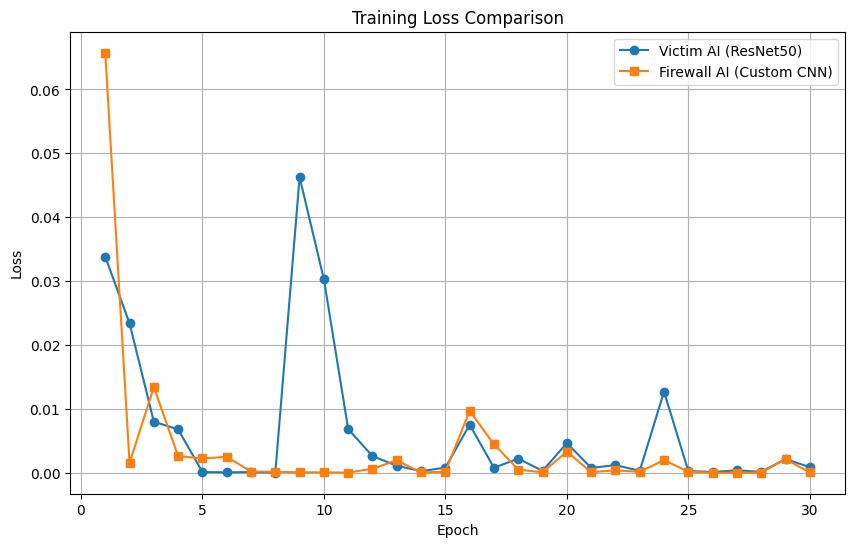


✅ TRAINING COMPLETE!

📊 Summary:
   Victim AI (ResNet50) - Final Loss: 0.0009
   Firewall AI (Custom CNN) - Final Loss: 0.0001

📁 Models saved to: /content/drive/MyDrive/AI_Firewall_For_Drones/models


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
from tqdm import tqdm #progress bar library
from google.colab import drive

drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/MyDrive/AI_Firewall_For_Drones"
DATASET_PATH = f"{DRIVE_PATH}/dataset_full/dataset"
BATCH_SIZE = 32 #number of images processes at once
IMG_SIZE = 128 #128*128 pixels
NUM_EPOCHS = 30

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),#resizes all images, to ensure all images are in same size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
class AdversarialDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']
        if not os.path.exists(img_path):
            img_path = os.path.join(DRIVE_PATH, img_path)

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row['true_label'], dtype=torch.float32)
        return image, label

#victim AI (Drone's AI that gets fooled)
class VictimAI(nn.Module):
    def __init__(self):
        super(VictimAI, self).__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        # Replace final layer for binary classification
        self.resnet.fc = nn.Linear(2048, 1)

    def forward(self, x):
        return torch.sigmoid(self.resnet(x))

#firewall AI (decides whether Drone's decision is correct)
class FirewallAI(nn.Module):
    def __init__(self):
        super(FirewallAI, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

print("\nLoading datasets...")

train_dataset = AdversarialDataset(
    os.path.join(DATASET_PATH, 'train.csv'),
    transform=train_transform
)
val_dataset = AdversarialDataset(
    os.path.join(DATASET_PATH, 'val.csv'),
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f" Train: {len(train_dataset)} images")
print(f" Validation: {len(val_dataset)} images")
print("\n Initializing models...")

victim_model = VictimAI().to(device)
firewall_model = FirewallAI().to(device)

print(f" Victim AI (ResNet50): {sum(p.numel() for p in victim_model.parameters()):,} parameters")
print(f" Firewall AI (Custom CNN): {sum(p.numel() for p in firewall_model.parameters()):,} parameters")
victim_optimizer = optim.Adam(victim_model.parameters(), lr=0.001)
firewall_optimizer = optim.Adam(firewall_model.parameters(), lr=0.001)
criterion = nn.BCELoss()

def train_victim_epoch(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0
    for images, labels in tqdm(loader, desc=f"Victim Epoch {epoch}", leave=False):
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def train_firewall_epoch(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0
    for images, labels in tqdm(loader, desc=f"Firewall Epoch {epoch}", leave=False):
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

print("\n" + "="*60)
print(" TRAINING BOTH MODELS")
print("="*60)

victim_losses = []
firewall_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n Epoch {epoch}/{NUM_EPOCHS}")
    print("-" * 40)
    victim_loss = train_victim_epoch(victim_model, train_loader, victim_optimizer, criterion, epoch)
    victim_losses.append(victim_loss)
    print(f"   Victim AI Loss: {victim_loss:.4f}")

    firewall_loss = train_firewall_epoch(firewall_model, train_loader, firewall_optimizer, criterion, epoch)
    firewall_losses.append(firewall_loss)
    print(f"   Firewall AI Loss: {firewall_loss:.4f}")

print("\n Saving models...")

models_path = os.path.join(DRIVE_PATH, 'models')
os.makedirs(models_path, exist_ok=True)
victim_path = os.path.join(models_path, 'victim_resnet50.pth')
torch.save(victim_model.state_dict(), victim_path)
print(f" Victim AI saved: {victim_path}")

firewall_path = os.path.join(models_path, 'firewall_cnn.pth')
torch.save(firewall_model.state_dict(), firewall_path)
print(f" Firewall AI saved: {firewall_path}")
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(victim_losses) + 1), victim_losses, label='Victim AI (ResNet50)', marker='o')
plt.plot(range(1, len(firewall_losses) + 1), firewall_losses, label='Firewall AI (Custom CNN)', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(DRIVE_PATH, 'training_losses.png'))
plt.show()

print("\n" + "="*60)
print(" TRAINING COMPLETE!")
print("="*60)
print(f"\n Summary:")
print(f"   Victim AI (ResNet50) - Final Loss: {victim_losses[-1]:.4f}")
print(f"   Firewall AI (Custom CNN) - Final Loss: {firewall_losses[-1]:.4f}")
print(f"\n Models saved to: {models_path}")
from google.colab import files
files.download(victim_path)
files.download(firewall_path)